In [3]:
# importer les packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# importer les données
df = pd.read_csv("/content/drive/MyDrive/Devoir /Dataset projet.csv")
df.head()

,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [6]:
# Ajout d'une colonne Fraude
df["FRAUDE"] = df["FraudResult"].apply(lambda x: "Fraude" if x == 1 else "Pas de fraude")
df.head()

,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult,FRAUDE
0,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0,Pas de fraude
1,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0,Pas de fraude
2,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0,Pas de fraude
3,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0,Pas de fraude
4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0,Pas de fraude


In [7]:
# Ajout des colonne (Date,jour,semaine,mois)
df["TransactionStartTime"] = pd.to_datetime(df["TransactionStartTime"])

# Nouvelles colonnes
df["DATE"] = df["TransactionStartTime"].dt.date
df["JOUR"] = df["TransactionStartTime"].dt.day_name()
df["SEMAINE"] = df["TransactionStartTime"].dt.isocalendar().week
df["MOIS"] = df["TransactionStartTime"].dt.month
df.head()

,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult,FRAUDE,DATE,JOUR,SEMAINE,MOIS
0,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,0,Pas de fraude,2018-11-15,Thursday,46,11
1,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,0,Pas de fraude,2018-11-15,Thursday,46,11
2,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,0,Pas de fraude,2018-11-15,Thursday,46,11
3,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,0,Pas de fraude,2018-11-15,Thursday,46,11
4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,0,Pas de fraude,2018-11-15,Thursday,46,11


In [8]:
# Affichage des données à travers l'utilisation de head ou tail
df.tail()

,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult,FRAUDE,DATE,JOUR,SEMAINE,MOIS
1995,ProductId_14,financial_services,ChannelId_3,23400.0,23400,2018-11-28 05:13:37+00:00,2,0,Pas de fraude,2018-11-28,Wednesday,48,11
1996,ProductId_3,airtime,ChannelId_3,1000.0,1000,2018-11-28 05:14:16+00:00,4,0,Pas de fraude,2018-11-28,Wednesday,48,11
1997,ProductId_6,financial_services,ChannelId_2,-50.0,50,2018-11-28 05:15:30+00:00,2,0,Pas de fraude,2018-11-28,Wednesday,48,11
1998,ProductId_1,airtime,ChannelId_3,1000.0,1000,2018-11-28 05:18:06+00:00,2,0,Pas de fraude,2018-11-28,Wednesday,48,11
1999,ProductId_15,financial_services,ChannelId_3,1200.0,1200,2018-11-28 05:21:00+00:00,2,0,Pas de fraude,2018-11-28,Wednesday,48,11


In [9]:
# Je veux voir la dimension des données
df.shape

(2000, 13)

In [ ]:
# les informations sur les données
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   ProductId             2000 non-null   object             
 1   ProductCategory       2000 non-null   object             
 2   ChannelId             2000 non-null   object             
 3   Amount                2000 non-null   float64            
 4   Value                 2000 non-null   int64              
 5   TransactionStartTime  2000 non-null   datetime64[ns, UTC]
 6   PricingStrategy       2000 non-null   int64              
 7   FraudResult           2000 non-null   int64              
 8   DATE                  2000 non-null   object             
 9   JOUR                  2000 non-null   object             
 10  SEMAINE               2000 non-null   UInt32             
 11  MOIS                  2000 non-null   int32              
 12  FRAUDE

In [10]:
# Transactions par date du debut
transactions_per_day = df.groupby('TransactionStartTime').size()
transactions_per_day

,0
TransactionStartTime,
2018-11-15 02:18:49+00:00,1
2018-11-15 02:19:08+00:00,1
2018-11-15 02:44:21+00:00,1
2018-11-15 03:32:55+00:00,1
2018-11-15 03:34:21+00:00,1
...,...
2018-11-28 05:13:37+00:00,1
2018-11-28 05:14:16+00:00,1
2018-11-28 05:15:30+00:00,1


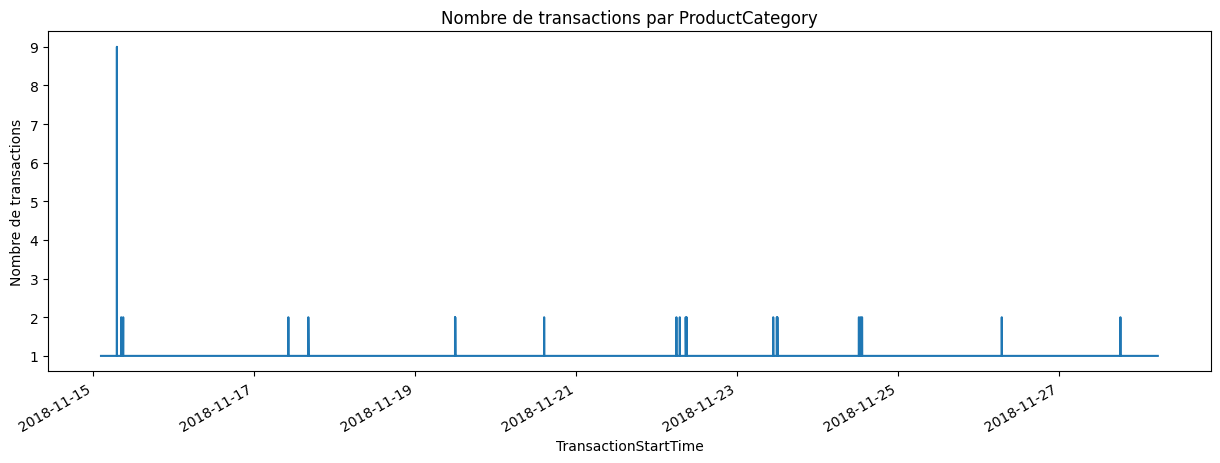

In [11]:
# Transactions par categories des produits
plt.figure(figsize=(15, 5))
transactions_per_day.plot() # lineplot
plt.title("Nombre de transactions par ProductCategory")
plt.xlabel("TransactionStartTime")
plt.ylabel("Nombre de transactions")
plt.show()

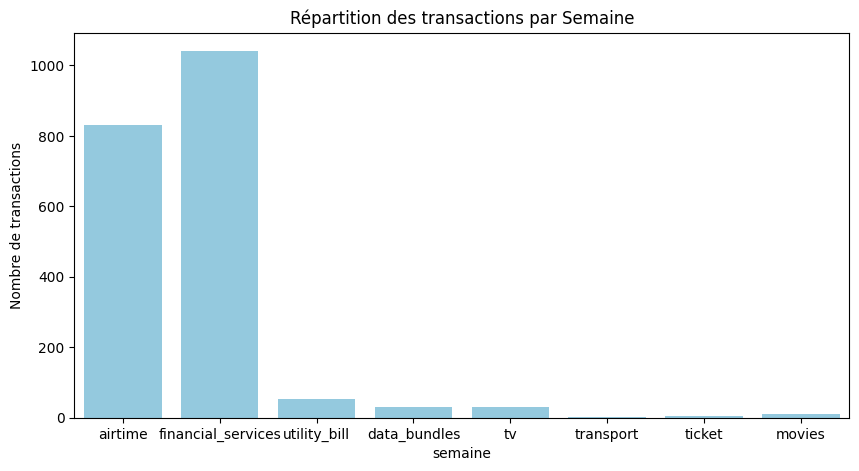

In [12]:
# Transactions par Semaine
plt.figure(figsize=(10, 5)) # créer la figure avec comme width = largeur = 10 et hauteur = height = 5
sns.countplot(data=df, x='ProductCategory', color='skyblue') # diagramme en bar
plt.title("Répartition des transactions par Semaine")
plt.xlabel("semaine")
plt.ylabel("Nombre de transactions")
plt.show()

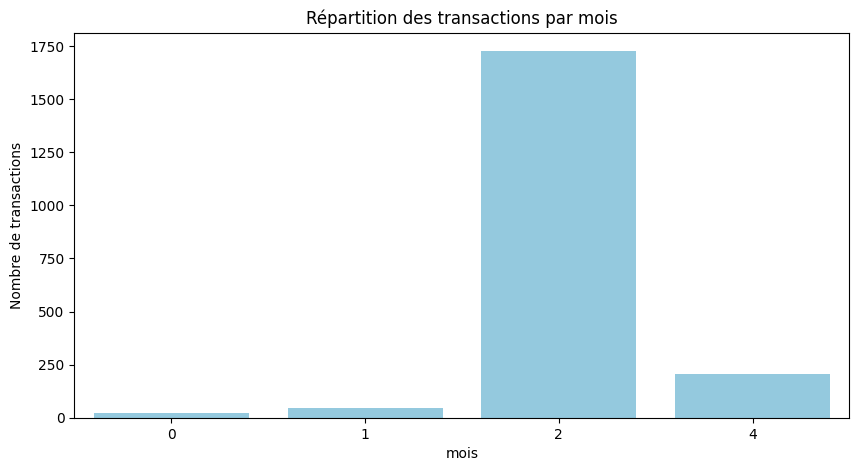

In [13]:
# Transactions par nois.
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='PricingStrategy', color='skyblue')
plt.title("Répartition des transactions par mois")
plt.xlabel("mois")
plt.ylabel("Nombre de transactions")
plt.show()

In [14]:
# Transactions par canal (pie chart)
channel_counts = df['ChannelId'].value_counts().reset_index()
channel_counts.columns = ['ChannelId', 'Count']
channel_counts

,ChannelId,Count
0,ChannelId_3,1152
1,ChannelId_2,811
2,ChannelId_1,19
3,ChannelId_5,18


In [15]:
#Repartition des transactions par canal
fig = px.pie(
    channel_counts,
    names='ChannelId',
    values='Count',
    title="Répartition des transactions par canal",
    color_discrete_sequence=["blue", "red", "green"])
fig.show()

In [16]:
# Taux de rentabilité par ProductCategory
rentabilite_cat_m = df.groupby('ProductCategory')['FraudResult'].mean().sort_values()

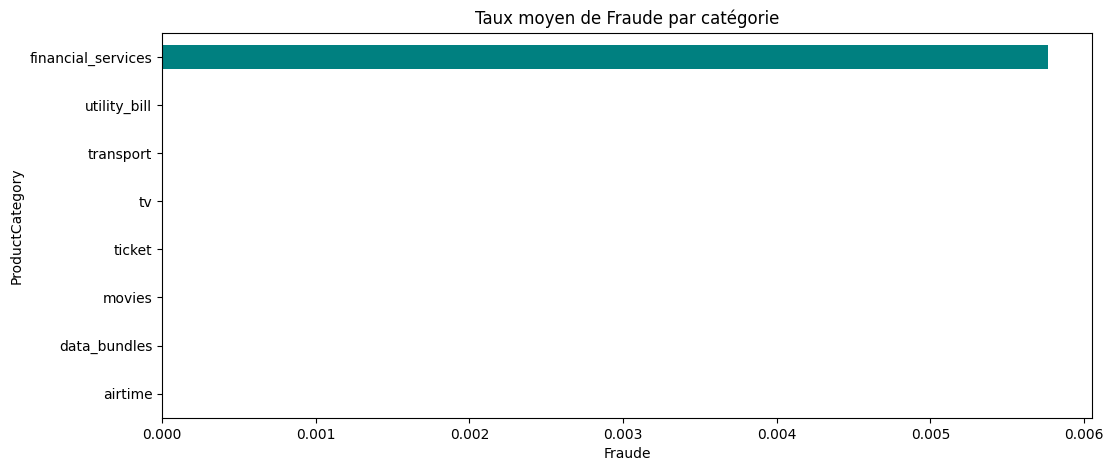

In [17]:
# Taux de moyen de FraudResult par catégorie
plt.figure(figsize=(12, 5))
rentabilite_cat_m.plot(kind='barh', color='teal') # kind= 'bar', kind = 'box'
plt.title("Taux moyen de Fraude par catégorie")
plt.xlabel("Fraude")
plt.show()

In [18]:
# matrice
df[['Amount', 'Value', 'PricingStrategy', 'FraudResult']].corr()

,Amount,Value,PricingStrategy,FraudResult
Amount,1.000000,0.988731,-0.244297,0.884853
Value,0.988731,1.000000,-0.216365,0.885626
PricingStrategy,-0.244297,-0.216365,1.000000,-0.149170
FraudResult,0.884853,0.885626,-0.149170,1.000000


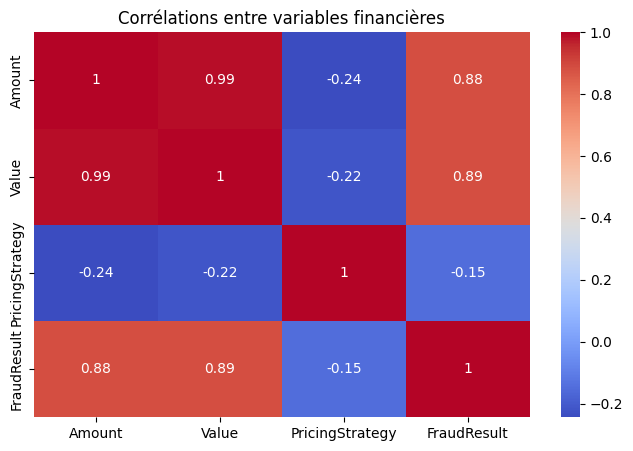

In [19]:
# Heatmap des corrélations
plt.figure(figsize=(8, 5))
sns.heatmap(df[['Amount', 'Value', 'PricingStrategy', 'FraudResult']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Corrélations entre variables financières")
plt.show()

In [20]:
# Revenus par catégorie
revenue_per_category = df.groupby('ProductCategory')['Value'].sum().sort_values(ascending=False).reset_index()

In [21]:
# Revenu total par catégorie de produit
fig = px.bar(revenue_per_category,
             x='ProductCategory', y='Value',
             title="Revenu total par catégorie de produit",
             color='Value')
fig.show()

In [24]:
# Marge moyenne par mois
Marge_moyenne_par_mois= df.groupby('MOIS')['Value'].mean().sort_values(ascending=False).reset_index()

<Figure size 1000x400 with 0 Axes>

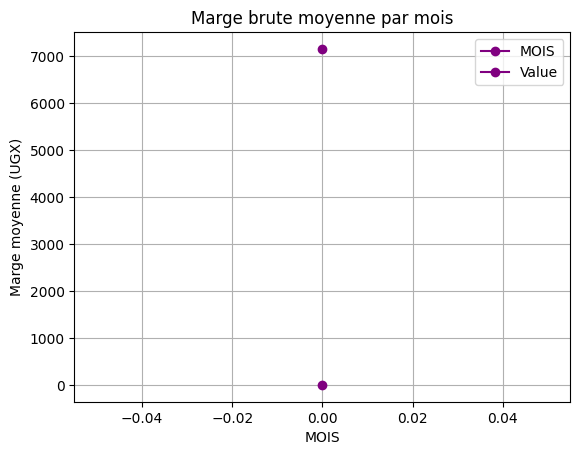

In [25]:
plt.figure(figsize=(10, 4))
Marge_moyenne_par_mois.plot(marker='o', color='purple')
plt.title("Marge brute moyenne par mois")
plt.xlabel("MOIS")
plt.ylabel("Marge moyenne (UGX)")
plt.grid(True)
plt.show()

In [26]:
# clients moins rentables
top_clients = df.groupby('ChannelId')['PricingStrategy'].sum().sort_values(ascending=False).tail(10).reset_index()

In [27]:
fig = px.bar(top_clients, x='ChannelId', y='PricingStrategy',
             title="Top 10 clients par marge brute",
             text='PricingStrategy')
fig.show()

In [28]:
# Catégories les plus concernées par les remboursements
remboursements = df[df['Amount'] < 0]

In [29]:
remboursements['ProductCategory'].value_counts().head()

,count
ProductCategory,
financial_services,786
airtime,37
utility_bill,3
tv,2
data_bundles,1


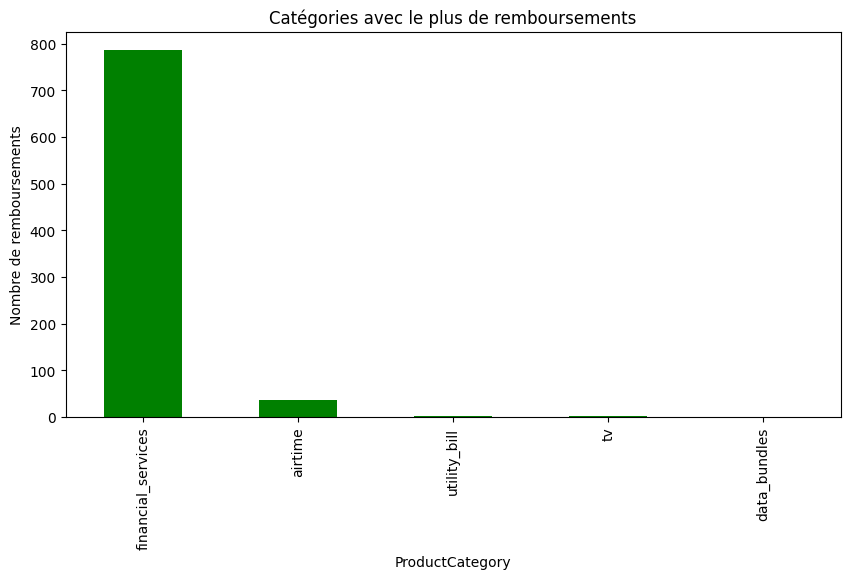

In [30]:
plt.figure(figsize=(10, 5))
remboursements['ProductCategory'].value_counts().head().plot(kind='bar', color='green')
plt.title("Catégories avec le plus de remboursements")
plt.xlabel("ProductCategory")
plt.ylabel("Nombre de remboursements")
plt.show()